In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torchvision.io import read_image
from torch.utils import data
import string
import os
from PIL import Image
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import time
import shutil

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Data Generation

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from random import randint, choice, uniform
import string
import time

fonts_drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets/fonts'
colors = {
  "black": 0x1c1c1c,
  "white": 0xfcfcfc,
}
image_width = 250
image_height = 70
font_size = 50
characters = [5,5]

def get_text():
  out_string = ""
  for i in range(randint(characters[0], characters[1])):
    out_string += choice(string.ascii_letters+"0123456789")
  return out_string

def draw_pixel(draw,x,y, thickness):
  if(thickness > 1):
    draw.line([(x, y), (x+thickness*([1,-1][randint(0, 1)]),y+thickness*([1,-1][randint(0, 1)]))], fill=colors["black"], width=thickness)
  else:
    draw.line([(x, y), (x,y)], fill=colors["black"])

def add_noise(draw, amount, thickness):
  for i in range(int(amount)):
    draw_pixel(draw, randint(0, image_width), randint(0, image_height), thickness)

def add_lines(draw, amount, thickness):

  thickness = 1
  wiggle_room_thickness = 2

  for i in range(int(amount)):
    wiggle_thickness = randint(thickness,thickness+wiggle_room_thickness)
    draw.line([(randint(0, image_width), randint(0, image_height)), (randint(0, image_width),randint(0, image_height))], fill=colors["black"],width=wiggle_thickness,)

def draw_characters(draw, image, text):
  
  fonts = ["ComicSansMS3.ttf","carbontype.ttf","Kingthings_Trypewriter_2.ttf","Sears_Tower.ttf","TravelingTypewriter.ttf"]
  wiggle_room_width = 48 - len(text) * 6
  wiggle_room_height = 13
  width_padding = 30
  font_size = 30
  wiggle_room_font_size = 10
  rotation_degrees = 20
  wiggle_room_rotation_percent = 0.4

  spacing_width = (image_width-width_padding) / len(text)
  next_letter_pos = width_padding/2


  for character in text:
    wiggle_width = uniform(0,wiggle_room_width)
    wiggle_height = uniform(0,wiggle_room_height)
    wiggle_font_size = uniform(font_size - wiggle_room_font_size / 2, font_size  + wiggle_room_font_size / 2)
    wiggle_rotation_degrees = rotation_degrees * uniform( -wiggle_room_rotation_percent,  wiggle_room_rotation_percent)
    font = ImageFont.truetype(fonts_drive_path+"/"+fonts[randint(0,len(fonts)-1)], int(wiggle_font_size))
    character_image = Image.new("RGB", (image_height, image_height), 255)
    draw = ImageDraw.Draw(character_image)
    draw.rectangle([0, 0, image_height, image_height], fill=colors["white"])
    draw.text((wiggle_width, wiggle_height), character, fill=colors["black"], font=font)
    character_image = character_image.rotate(wiggle_rotation_degrees, expand=True, fillcolor="white")
    image.paste(character_image, (int(next_letter_pos), 0))
    next_letter_pos += spacing_width

def generate_data(num_samples, drive_path):
  text_done = []
  start = time.time()
  for i in range(int(num_samples)):

    image = Image.new('RGB',(image_width, image_height))
    draw = ImageDraw.Draw(image)
    draw.rectangle([0, 0, image_width, image_height], fill=colors["white"])

    text = get_text()
    if(text not in text_done):
      text_done.append(text)
    else:
      print("Skipped")
      continue
    draw_characters(draw, image, text)

    add_noise(draw, amount=int(image_width*image_height*0.001), thickness = 1)
    add_noise(draw, amount=int(image_width*image_height*0.001), thickness = 2)
    add_noise(draw, amount=int(image_width*image_height*0.001), thickness = 3)
    add_lines(draw, amount=1, thickness=2)
    add_lines(draw, amount=1, thickness=3)


    image.save(drive_path+"/"+text+".jpg")
  end = time.time()
  print("Operation completed. Time taken: "+str(end - start)+" seconds")

num_samples_train = input("How many images do you want to generate for training?")
drive_path_train = '/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Training'
num_samples_validation = input("How many images do you want to generate for validation?")
drive_path_validation = '/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Validation'
num_samples_testing = input("How many images do you want to generate for testing?")
drive_path_testing = '/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Testing'
generate_data(num_samples_train, drive_path_train)
generate_data(num_samples_validation, drive_path_validation)
generate_data(num_samples_testing, drive_path_testing)

KeyboardInterrupt: ignored

# Data Loader

In [ ]:
# os.listdir(drive_path+"/training")
# print(train_data.__getitem__(10))

In [ ]:
#To Enable GPU Usage
use_cuda = True

In [ ]:
all_characters = string.ascii_letters+"0123456789"
all_characters

'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

In [ ]:
def string_label(string):
  out = []
  index = 0
  for char_string in string:
    for char_index in range(0,len(all_characters)):
      if char_string == all_characters[char_index]:
        out.append(int(char_index))
        break
  return out

In [ ]:
class CAPTCHAImageDataset(data.Dataset):
  def __init__(self, img_dir, transform=None):
    self.all_images = os.listdir(img_dir)
    self.img_dir = img_dir
    self.transform = transform

  def __len__(self):
    return len(self.all_images)

  def __getitem__(self, idx):
    img_path = self.all_images[idx]
    # print(img_path)
    label = img_path.split("/")[-1]
    label = img_path.split("-")[0]
    label = label.replace(".jpg","")
    # print(label)
    image = Image.open(self.img_dir + "/" + img_path)
    if self.transform:
        image = self.transform(image)
    labels = torch.Tensor(string_label(label))
    labels = labels.type(torch.LongTensor)
    labels = labels.squeeze(0)
    return image, labels

# Data Pre Processing
Process the data by adding a filter, inverting colors, ensuring black and white

In [ ]:
# Image pre-processing
def remove_noise_and_grayscale(img_path):
  img = cv2.imread(img_path)
  gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  gray_median = cv2.medianBlur(gray_img, 3)
  gray_thresh = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY_INV, cv2.THRESH_OTSU)[1]
  return gray_thresh

# cv2_imshow(cv2.imread('/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Training/0By1b.jpg'))
# gray_img = remove_noise_and_grayscale('/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Training/0By1b.jpg')
# cv2_imshow(gray_img)

def generate_processed_data_folder(input_path, output_path):
  # shutil.rmtree(output_path)
  if not os.path.exists(output_path):
    os.mkdir(output_path)
    print(output_path)
  for dir in os.listdir(input_path):
    out_dir_path = os.path.join(output_path, dir)
    if not os.path.exists(out_dir_path):
      os.mkdir(out_dir_path)
      print(out_dir_path)
    in_dir_path = os.path.join(input_path, dir)
    print("Processing images in: " + dir)
    for img in os.listdir(in_dir_path):
      if os.path.isfile(os.path.join(in_dir_path, img)) and not os.path.isfile(os.path.join(out_dir_path, img)):
        in_img_path = os.path.join(in_dir_path, img)
        out_img_path = os.path.join(out_dir_path, img)
        processed_img = remove_noise_and_grayscale(in_img_path)
        print(in_img_path, out_img_path)
        if not cv2.imwrite(out_img_path, processed_img):
          raise Exception("Could not write image: {}".format(out_img_path))
  print("Done processing")

# def create_baseline_split_data(input_path, output_path):
#   if not os.path.exists(output_path):
#     os.mkdir(output_path)

#   for dir in os.listdir(input_path):
#     out_dir_path = os.path.join(output_path, dir)
#     if not os.path.exists(output_path):
#       os.mkdir(out_dir_path)
#     in_dir_path = os.path.join(input_path, dir)
#     print("Processing images in: " + dir)
#     image_count = 0
#     for img in os.listdir(in_dir_path):
#       image_count+=1
#       if os.path.isfile(os.path.join(in_dir_path, img)):
#         in_img_path = os.path.join(in_dir_path, img)
#         transform = transforms.Compose([transforms.PILToTensor()])
#         label = in_img_path.split("/")[-1]
#         label = label.replace(".jpg","")
#         current_label = 0
#         img_pil = Image.open(in_img_path)
#         num_chars = 5
#         for index in range(0,num_chars):
#           w,h = img_pil.size
#           start_w = int(index * w/num_chars)
#           end_w = int(min(w, (index+1) * w/num_chars))
#           img_split = img_pil.crop((start_w,0,end_w,h))
#           img_split.show()
#           if not os.path.exists(out_dir_path+"/"+str(label[current_label])):
#             os.mkdir(out_dir_path+"/"+str(label[current_label]))
#           out_img_path = os.path.join(out_dir_path+"/"+str(label[current_label]), str(label[current_label])+"-"+str(image_count)+".jpg")
#           img_split.save(out_img_path)
#           current_label+=1
#           image_count+=1
#     print("Processed:", image_count, "character images")
#   print("Done processing")

In [ ]:
def get_data_loader(batch_size, is_split_data=False):
  transform = transforms.Compose([transforms.Resize((70,250)),transforms.ToTensor()])
  if is_split_data==True:
    transform = transforms.Compose([transforms.Resize((224,1120)),transforms.ToTensor()])
  train_data = CAPTCHAImageDataset(drive_path + "/Training", transform=transform)
  val_data = CAPTCHAImageDataset(drive_path + "/Validation", transform=transform)
  test_data = CAPTCHAImageDataset(drive_path + "/Testing", transform=transform)
  
  # print(train_data.__getitem__(1))
  train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,num_workers=1,shuffle=True)
  val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size,num_workers=1,shuffle=True)
  test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,num_workers=1,shuffle=True)
    
  return train_loader, val_loader, test_loader

In [ ]:
# Process data for the baseline model (estimate where the character is and split up the image accordingly)
# Data splitting now happens when training the baseline model!
# drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets'
# create_baseline_split_data(drive_path + '/project_dataset_processed', drive_path + '/baseline_split')

In [ ]:
# drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets/baseline_split'
# train_loader, val_loader, test_loader = get_data_loader(1, is_split_data=True)

In [ ]:
# Process the data by adding a filter, inverting colors, ensuring black and white
drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets'

generate_processed_data_folder(drive_path + '/project_dataset', drive_path + '/project_dataset_processed')

Streaming output truncated to the last 5000 lines.
/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Training/kpEw6.jpg /content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed/Training/kpEw6.jpg
/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Training/gDCu9.jpg /content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed/Training/gDCu9.jpg
/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Training/JGMKC.jpg /content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed/Training/JGMKC.jpg
/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Training/0NENk.jpg /content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed/Training/0NENk.jpg
/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Training/MXU2O.jpg /content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed/Training/MXU2O.jpg
/content/gdrive/My Drive/Colab Notebooks/Datasets

In [ ]:
drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets'
project_dataset_path = drive_path + '/project_dataset'
project_dataset_p_path = drive_path + '/project_dataset_processed'
print(len(os.listdir(os.path.join(project_dataset_path, 'Validation'))))
print(len(os.listdir(os.path.join(project_dataset_p_path, 'Validation'))))

4049
4049


In [ ]:
drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed'
train_loader, val_loader, test_loader = get_data_loader(128)

In [ ]:
len(train_loader)
# for images, labels in train_loader:
#   print(labels)
#   print(images)

123

In [ ]:
len(val_loader)

16

In [ ]:
len(test_loader)

15

torch.Size([1, 5])
torch.Size([1, 70, 250])


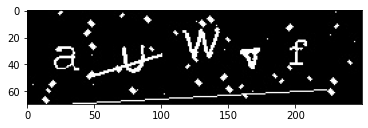

In [ ]:
# Preview a test image
for image, label in test_loader:
  image = torch.squeeze(image, dim=0)
  img_np = image.numpy()
  plt.imshow(img_np.transpose(1,2,0)[:,:,0], cmap='gray')
  print(label.shape)
  print(image.shape)
  break

# Baseline CNN

In [ ]:
def get_model_name(name, batch_size, learning_rate, epoch):
  """ Generate a name for the model consisting of all the hyperparameter values"""
  path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,batch_size,learning_rate,epoch)
  return path

In [ ]:
def get_accuracy(model, data_loader):
  correct = 0
  total = 0
  for imgs, labels in data_loader:
    all_imgs_array = []
    all_imgs = torch.Tensor()
    for img in imgs:
      split_imgs = split_image(img)
      for split_img in split_imgs:
        all_imgs_array.append(split_img)
    all_imgs = torch.stack(all_imgs_array)

    all_labels = torch.flatten(labels, start_dim=0, end_dim=1)

    #To Enable GPU Usage
    if use_cuda and torch.cuda.is_available():
      all_imgs = all_imgs.cuda()
      all_labels = all_labels.cuda()
        
    output = model(all_imgs)
    #select index with maximum prediction score
    pred = output.max(1, keepdim=True)[1]
    correct += pred.eq(all_labels.view_as(pred)).sum().item()
    total += all_imgs.shape[0]
    if total == 0:
      return 0
  return correct / total

In [ ]:
device = torch.device('cpu')
if use_cuda and torch.cuda.is_available():
  device = torch.device('cuda')

In [ ]:
class CNNCharNet(nn.Module):
  def __init__(self):
    super(CNNCharNet, self).__init__()
    self.name = "CNNCharNet"
    # (224 - 5 + 2*0) / 1 + 1 = 220 x 220 (5 channels)
    self.conv1 = nn.Conv2d(1,5,5) 
    # (220 - 2 + 2*0) / 2 + 1 = 110 x 110 (5 channels)
    self.pool = nn.MaxPool2d(2,2)
    # (110 - 5 + 2*0) / 1 + 1 = 106 x 106 (10 channels)
    self.conv2 = nn.Conv2d(5,10,5)
    # (106 - 2 + 2*0) / 2 + 1 = 53 x 53 (10 channels)
    # self.fc1 = nn.Linear(53*53*10, 32)
    # self.fc2 = nn.Linear(32,len(all_characters))
    self.fc1 = nn.Linear(53*53*10, len(all_characters))

  def forward(self,x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1,53*53*10)
    x = F.relu(self.fc1(x))
    x = F.softmax(x)
    return x

In [ ]:
def split_image(img, num_chars=5):
  imgs = []
  c, h, w = img.size()
  for i in range(num_chars):
    start_w = int(i * w/num_chars)
    end_w = int(min(w, (i+1) * w/num_chars))
    img_cropped = img[:, :, start_w:end_w]
    imgs.append(img_cropped)
    # print(img_cropped.size())
  return imgs

def train(model, train_loader, val_loader, test_laoder, batch_size=64, learning_rate=0.001, num_epochs=30):
  # Check GPU availability
  if use_cuda and torch.cuda.is_available():
    model.cuda()
    print('CUDA is available!  Training on GPU ...')
  else:
    print('CUDA is not available.  Training on CPU ...')
      
  # Fixed PyTorch random seed for reproducible result
  torch.manual_seed(1000)
    
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  iters, losses, train_acc, val_acc = [], [], [], []

  print("Training...")
  start_time = time.time()

  # training
  n = 0 # the number of iterations
  # Set up some numpy arrays to store the accuracy
  for epoch in range(num_epochs):
    for imgs, labels in iter(train_loader):
      # print(labels)
      all_imgs_array = []
      all_imgs = torch.Tensor()
      # print(imgs.size())
      for img in imgs:
        split_imgs = split_image(img)
        for split_img in split_imgs:
          all_imgs_array.append(split_img)
      all_imgs = torch.stack(all_imgs_array)

      all_labels = torch.flatten(labels, start_dim=0, end_dim=1)
      
      #To Enable GPU Usage
      if use_cuda and torch.cuda.is_available():
        all_imgs = all_imgs.cuda()
        all_labels = all_labels.cuda()
      out = model(all_imgs)         # forward pass
      loss = criterion(out, all_labels) # compute the total loss
      loss.backward()               # backward pass (compute parameter updates)
      optimizer.step()              # make the updates for each parameter
      optimizer.zero_grad()         # a clean up step for PyTorch

    # save the current training information
    iters.append(n)
    losses.append(float(loss)/batch_size)             # compute *average* loss
    train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy 
    val_acc.append(get_accuracy(model, val_loader))  # compute validation accuracy
    n += 1

    print(("Epoch {}: Train accuracy: {} | Validation accuracy: {}").format(epoch + 1,train_acc[epoch],val_acc[epoch]))

    # Save the current model (checkpoint) to a file
    model_path = get_model_name(model.name, batch_size, learning_rate, epoch)
    torch.save(model.state_dict(), model_path)
    
  print('Finished Training')
  end_time = time.time()
  elapsed_time = end_time - start_time
  print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    
  # plotting
  import matplotlib.pyplot as plt
  plt.title("Training Curve")
  plt.plot(iters, losses, label="Train")
  plt.xlabel("Iterations")
  plt.ylabel("Loss")
  plt.show()

  plt.title("Training Curve")
  plt.plot(iters, train_acc, label="Train")
  plt.plot(iters, val_acc, label="Validation")
  plt.xlabel("Iterations")
  plt.ylabel("Training Accuracy")
  plt.legend(loc='best')
  plt.show()

  print("Final Training Accuracy: {}".format(train_acc[-1]))
  print("Final Validation Accuracy: {}".format(val_acc[-1]))

CUDA is available!  Training on GPU ...
Training...


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:21: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.


Epoch 1: Train accuracy: 0.03213333333333333 | Validation accuracy: 0.02872
Epoch 2: Train accuracy: 0.07096 | Validation accuracy: 0.0512
Epoch 3: Train accuracy: 0.09686666666666667 | Validation accuracy: 0.062
Epoch 4: Train accuracy: 0.11692 | Validation accuracy: 0.0732
Epoch 5: Train accuracy: 0.13566666666666666 | Validation accuracy: 0.07704
Epoch 6: Train accuracy: 0.147 | Validation accuracy: 0.07704
Epoch 7: Train accuracy: 0.15933333333333333 | Validation accuracy: 0.08168
Epoch 8: Train accuracy: 0.16962666666666668 | Validation accuracy: 0.086
Epoch 9: Train accuracy: 0.17996 | Validation accuracy: 0.08936
Epoch 10: Train accuracy: 0.1852 | Validation accuracy: 0.08904
Epoch 11: Train accuracy: 0.19202666666666668 | Validation accuracy: 0.0896
Epoch 12: Train accuracy: 0.19774666666666665 | Validation accuracy: 0.08944
Epoch 13: Train accuracy: 0.20398666666666668 | Validation accuracy: 0.09136
Epoch 14: Train accuracy: 0.20746666666666666 | Validation accuracy: 0.09256
E

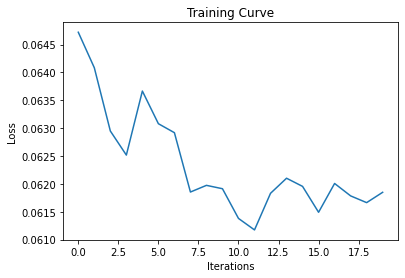

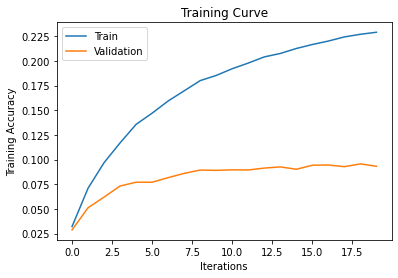

Final Training Accuracy: 0.22897333333333333
Final Validation Accuracy: 0.0932


In [ ]:
# Process data for the baseline model (estimate where the character is and split up the image accordingly)
drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed'
train_loader, val_loader, test_loader = get_data_loader(64, is_split_data=True)
model = CNNCharNet()
train(model, train_loader, val_loader, test_loader, batch_size=64, learning_rate=0.001, num_epochs=20)

In [ ]:
# Get the accuracy of the baseline
model_path = get_model_name(model.name, batch_size=64, learning_rate=0.001, epoch=20-1)
print(model_path)
state = torch.load(model_path)
model.load_state_dict(state)

if torch.cuda.is_available():
  model.cuda()
get_accuracy(model, test_loader)

model_CNNCharNet_bs64_lr0.001_epoch19


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:21: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.


0.0928

# Primary Model
Bidrectional LSTM

In [ ]:
for img, labels in test_loader:
  print(img)
  print(labels)
  break

tensor([[[[0.0000, 0.0000, 0.0118,  ..., 0.0000, 0.0000, 0.0000],
          [0.0118, 0.0039, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0118, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0078, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0118, 0.0000, 0.0118,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0039, 0.0000, 0.0000,  ..., 0.0039, 0.0000, 0.0000],
          [0.0000, 0.0118, 0.0039,  ..., 0.0039, 0.0039, 0.0000],
          [0.0000, 0.0078, 0.0000,  ..

In [ ]:
# # Bidirectional recurrent neural network
# class BiRNN(nn.Module):
#     def __init__(self, input_size, n_hidden, n_layers):
#         super(BiRNN, self).__init__()
#         self.name = 'BiRNN'
#         self.input_size = input_size
#         self.n_hidden = n_hidden
#         self.n_layers = n_layers
#         self.lstm = nn.LSTM(input_size, n_hidden, n_layers, batch_first=True, bidirectional=True)
#         self.fc = nn.Linear(n_hidden*2, 1) #2 for bidirectional
    
#     def forward(self, x):
#         # Set initial states
#         h_0 = torch.zeros(self.n_layers*2, x.size(0), self.n_hidden)
#         c_0 = torch.zeros(self.n_layers*2, x.size(0), self.n_hidden)
        
#         # Forward propagate LSTM
#         output, hidden = self.lstm(x, (h_0, c_0))
        
#         # Decode the hidden state of the last time step
#         output = self.fc(output[:, -1, :])
#         output = F.softmax(output)
#         return output

# model = BiRNN(input_size = len(all_characters),n_hidden = 10,n_layers = 2)

In [ ]:
# class CAPTCHANet(nn.Module):
#   def __init__(self, input_size, hidden_size, num_layers, num_classes):
#     super(CAPTCHANet, self).__init__()
#     self.name = "CAPTCHANet"
#     self.emb = torch.eye(input_size)
#     self.hidden_size = hidden_size
#     self.num_layers = num_layers
#     self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional = True)
#     self.fc = nn.Linear(hidden_size * 2, num_classes) # multiply by 2 -> one forward, one backward
    
#   def forward(self, x):
#     h0 = torch.zeros(self.num_layers*2, x.size(0), self.hidden_size).to(device) # multiply by 2 -> one forward, one backward
#     c0 = torch.zeros(self.num_layers*2, x.size(0), self.hidden_size).to(device) # multiply by 2 -> one forward, one backward
    
#     print(x[0][0].size(0))
#     print(len(all_characters))
#     x = self.emb(x)
#     print("OK")
#     out, _ = self.rnn(x, (h0, c0))
#     out = torch.cat([torch.max(out, dim=1)[0], torch.mean(out, dim=1)], dim=1)
#     return out

In [ ]:
# model = CAPTCHANet(len(all_characters), hidden_size = 10, num_layers=2, num_classes = 1)
# train_loader, val_loader, test_loader = get_data_loader(1)
# train(model, train_loader, val_loader, num_epochs=5, learning_rate=0.001, batch_size=256)

In [ ]:
# def train(model, train_loader, valid_loader, num_epochs=5, learning_rate=1e-3, batch_size=256):
#   # Check GPU availability
#   if use_cuda and torch.cuda.is_available():
#     model.cuda()
#     print('CUDA is available!  Training on GPU ...')
#   else:
#     print('CUDA is not available.  Training on CPU ...')
    
#   start_time = time.time()

#   torch.manual_seed(42)
#   criterion = nn.CrossEntropyLoss()
#   optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#   train_acc, valid_acc, losses, iters = [], [], [], []
#   n = 0 # the number of iterations
  
#   for epoch in range(num_epochs):
#     total_train_loss = 0.0
#     for imgs, labels in iter(train_loader):
#       if use_cuda and torch.cuda.is_available():
#         imgs = imgs.cuda()
#         labels = labels.cuda()
#       pred = model(imgs)            # forward pass
#       loss = criterion(pred, labels)# compute the total loss
#       loss.backward()               # backward pass (compute parameter updates)
#       optimizer.step()              # make the updates for each parameter
#       optimizer.zero_grad()         # a clean up step for PyTorch
      
#     # save the current training information
#     iters.append(n)
#     losses.append(float(loss)/batch_size)               # compute *average* loss
#     train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy 
#     valid_acc.append(get_accuracy(model, val_loader))   # compute validation accuracy
#     n += 1


#     print(("Epoch {}: Train accuracy: {} | Validation accuracy: {}").format(epoch + 1,train_acc[epoch],val_acc[epoch]))

#     # Save the current model (checkpoint) to a file
#     model_path = get_model_name(model.name, batch_size, learning_rate, epoch)
#     torch.save(model.state_dict(), model_path)

#     print('Finished Training')
#     end_time = time.time()
#     elapsed_time = end_time - start_time
#     print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    
#     # plotting
#     import matplotlib.pyplot as plt
#     plt.title("Training Curve")
#     plt.plot(iters, losses, label="Train")
#     plt.xlabel("Iterations")
#     plt.ylabel("Loss")
#     plt.show()

#     plt.title("Training Curve")
#     plt.plot(iters, train_acc, label="Train")
#     plt.plot(iters, valid_acc, label="Validation")
#     plt.xlabel("Iterations")
#     plt.ylabel("Training Accuracy")
#     plt.legend(loc='best')
#     plt.show()

#     print("Final Training Accuracy: {}".format(train_acc[-1]))
#     print("Final Validation Accuracy: {}".format(valid_acc[-1]))

In [ ]:
class CLSTM(nn.Module):
  def __init__(self, input_size=256, hidden_size=128, num_class=62):
    super(CLSTM, self).__init__()
    self.name = "CLSTM"
    self.conv1 = nn.Conv2d(1, 64, kernel_size=3)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(64, 128, kernel_size=3)
    self.fc1 = nn.Linear(16*128, input_size)
    self.dropout = nn.Dropout(0.3)
    self.rnn = nn.LSTM(input_size=256, hidden_size=128, bidirectional=True, num_layers=2, batch_first=True)
    self.fc2 = nn.Linear(hidden_size*2, num_class+1)

  def forward(self, x):
    batch_size = x.size(0)
    x = F.relu(self.conv1(x))
    x = self.pool(x)
    x = F.relu(self.conv2(x))
    x = self.pool(x)
    # Bring the width to the middle
    x = x.permute(0, 3, 1, 2)
    x = x.view(batch_size, x.size(1), -1)
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x, _ = self.rnn(x)
    x = self.fc2(x)
    # Put in required shape for to get CTC loss
    x = x.permute(1, 0, 2)
    return x

model = CLSTM()
for images, labels in test_loader:
  output = model(images)
  break

In [ ]:
def train_CLSTM(model, train_loader, val_loader, batch_size=128, num_epochs=400, lr=1e-4):
  drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed'
  train_loader_single, val_loader_single, test_loader_single = get_data_loader(1)

  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  criterion = nn.CTCLoss(blank=0)
  iters_loss, iters_acc, train_losses, valid_losses, train_accs, val_accs = [], [], [], [], [], []

  for epoch in range(num_epochs):
    train_loss = 0
    for images, labels in train_loader:
      images = images.cuda()
      labels = labels.cuda()
      labels = labels + 1 #account for unknown

      optimizer.zero_grad()
      preds = model(images)
      log_probs = F.log_softmax(preds, 2)
      pred_lengths = torch.full(size=(preds.size(1),), fill_value=log_probs.size(0), dtype=torch.int32)
      label_lengths = torch.full(size=(preds.size(1),), fill_value=labels.size(1), dtype=torch.int32)
      loss = criterion(log_probs, labels, pred_lengths, label_lengths)
      loss.backward()
      optimizer.step()
      train_loss += loss.item() 

    iters_loss.append(epoch)
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    valid_loss = 0
    for images, labels in val_loader:
      images = images.cuda()
      labels = labels.cuda()
      labels = labels + 1 #account for unknown

      preds = model(images)
      log_probs = F.log_softmax(preds, 2)
      pred_lengths = torch.full(size=(preds.size(1),), fill_value=log_probs.size(0), dtype=torch.int32)
      label_lengths = torch.full(size=(preds.size(1),), fill_value=labels.size(1), dtype=torch.int32)
      loss = criterion(log_probs, labels, pred_lengths, label_lengths)
      valid_loss += loss.item()

    valid_loss /= len(val_loader)
    valid_losses.append(valid_loss)

    print("Epoch: {} Train Loss: {} Valid Loss: {}".format(epoch, train_loss, valid_loss))
    if ((epoch + 1) % 10 == 0):
      if epoch != 99:
        model_path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(model.name,128,1e-4,epoch + 1)
        torch.save(model.state_dict(), model_path)
        print("saving")

  plt.title("Training Curve")
  plt.plot(iters_loss, train_losses, label="Train")
  plt.plot(iters_loss, valid_losses, label="Validation")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend(loc='best')
  plt.show()

Epoch: 0 Train Loss: 13.199018207022814 Valid Loss: 4.475230649113655
Epoch: 1 Train Loss: 4.4662934396325085 Valid Loss: 4.462805286049843
Epoch: 2 Train Loss: 4.461717148137287 Valid Loss: 4.4628137946128845
Epoch: 3 Train Loss: 4.461492426027127 Valid Loss: 4.462813854217529
Epoch: 4 Train Loss: 4.461309677217065 Valid Loss: 4.462650641798973
Epoch: 5 Train Loss: 4.46104479999077 Valid Loss: 4.463007614016533
Epoch: 6 Train Loss: 4.460928250134476 Valid Loss: 4.462353557348251
Epoch: 7 Train Loss: 4.460295944679074 Valid Loss: 4.462246671319008
Epoch: 8 Train Loss: 4.459865256053646 Valid Loss: 4.461090609431267
Epoch: 9 Train Loss: 4.459069872290138 Valid Loss: 4.460242047905922
saving
Epoch: 10 Train Loss: 4.457847913106282 Valid Loss: 4.459455370903015
Epoch: 11 Train Loss: 4.456158979152276 Valid Loss: 4.456818491220474
Epoch: 12 Train Loss: 4.453522472846799 Valid Loss: 4.453202486038208
Epoch: 13 Train Loss: 4.445944828715751 Valid Loss: 4.440089792013168
Epoch: 14 Train Loss:

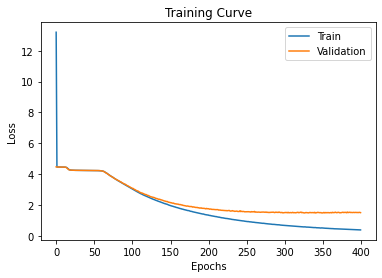

In [ ]:
model = CLSTM()
model = model.cuda()
train_CLSTM(model, train_loader, val_loader)
model_path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(model.name,128,1e-4,400)
torch.save(model.state_dict(), model_path)

In [ ]:
drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed'
train_loader_single, val_loader_single, test_loader_single = get_data_loader(1)

model = CLSTM()
model = model.cuda()
model.load_state_dict(torch.load('/content/model_CLSTM_bs128_lr0.0001_epoch400'))

def decode_pred(preds):
  preds = preds.permute(1, 0, 2)
  preds = torch.softmax(preds, 2)
  preds = torch.argmax(preds, 2)
  decoded_preds = []
  for pred in preds:
    decoded_pred = []
    len = 0
    for idx in pred:
      if idx != 0:
        decoded_pred.append(all_characters[int(idx) - 1])
        len += 1
        if len == 5:
          break
    
    decoded_preds.append(decoded_pred)
  return decoded_preds

def decode_labels(labels):
  # print(labels)
  decoded_labels = []
  for label in labels:
    decoded_label = []
    for idx in label:
      decoded_label.append(all_characters[idx])
    decoded_labels.append(decoded_label)
  return decoded_labels


def get_accuracy(model, loader):
  correct = 0
  for images, labels in loader:
    images = images.cuda()
    pred = model(images)
    dec_pred = decode_pred(pred)
    dec_label = decode_labels(labels)
    for i in range(len(dec_label[0])):
      if (i+1) < len(dec_pred[0]) and dec_pred[0][i] == dec_label[0][i]:
        correct += 1

  accuracy = correct/(len(loader) * 5)
  return accuracy

acc = get_accuracy(model, val_loader_single)
print("Vall acc: {}".format(acc))

NameError: ignored

epochs: [0, 10]
val accs: [0.0, 0.0]
train accs: [0.0, 0.0]
epochs: [0, 10, 20]
val accs: [0.0, 0.0, 0.010521116325018523]
train accs: [0.0, 0.0, 0.009668789808917198]
epochs: [0, 10, 20, 30]
val accs: [0.0, 0.0, 0.010521116325018523, 0.009681402815510002]
train accs: [0.0, 0.0, 0.009668789808917198, 0.01072611464968153]
epochs: [0, 10, 20, 30, 40]
val accs: [0.0, 0.0, 0.010521116325018523, 0.009681402815510002, 0.010570511237342553]
train accs: [0.0, 0.0, 0.009668789808917198, 0.01072611464968153, 0.012547770700636942]
epochs: [0, 10, 20, 30, 40, 50]
val accs: [0.0, 0.0, 0.010521116325018523, 0.009681402815510002, 0.010570511237342553, 0.010817485798962707]
train accs: [0.0, 0.0, 0.009668789808917198, 0.01072611464968153, 0.012547770700636942, 0.013171974522292993]
epochs: [0, 10, 20, 30, 40, 50, 60]
val accs: [0.0, 0.0, 0.010521116325018523, 0.009681402815510002, 0.010570511237342553, 0.010817485798962707, 0.016794270190170414]
train accs: [0.0, 0.0, 0.009668789808917198, 0.010726114

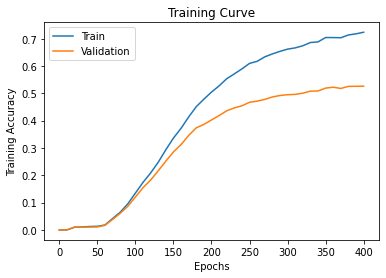

In [ ]:
def generate_graph_data():
  epochs, train_accs, val_accs = [], [], []

  epochs.append(0)
  train_accs.append(0.0)
  val_accs.append(0.0)

  for i in range(10, 410, 10):
    if i != 100:
      model = CLSTM()
      model = model.cuda()
      model_path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(model.name,128,1e-4,i)
      model.load_state_dict(torch.load(model_path))

      epochs.append(i)

      train_loader_single, val_loader_single, test_loader_single = get_data_loader(1)
      train_accs.append(get_accuracy(model, train_loader_single))
      val_accs.append(get_accuracy(model, val_loader_single))
      print("epochs: {}".format(epochs))
      print("val accs: {}".format(val_accs))
      print("train accs: {}".format(train_accs))

  plt.title("Training Curve")
  plt.plot(epochs, train_accs, label="Train")
  plt.plot(epochs, val_accs, label="Validation")
  plt.xlabel("Epochs")
  plt.ylabel("Training Accuracy")
  plt.legend(loc='best')
  plt.show()


generate_graph_data()

In [ ]:
train_accs = [0.0, 0.0, 0.009859872611464968, 0.010789808917197453, 0.013363057324840765, 0.015031847133757962, 0.03211464968152866, 0.05419108280254777, 0.08047133757961783, 0.09649681528662421, 0.09005095541401274, 0.14239490445859873, 0.1699235668789809, 0.20080254777070064, 0.23828025477707007, 0.27845859872611467, 0.31142675159235667, 0.3516050955414013, 0.39038216560509553, 0.4108152866242038, 0.4487388535031847]
val_accs = [0.0, 0.0, 0.010372931588046431, 0.008446530007409237, 0.010323536675722401, 0.014028155100024697, 0.027315386515188937, 0.04687577179550506, 0.0704865398863917, 0.08446530007409236, 0.07942701901704124, 0.1259570264262781, 0.1503581131143492, 0.172585823660163, 0.20617436404050382, 0.23378612002963695, 0.2609533218078538, 0.29928377377130155, 0.3268955297604347, 0.3475919980242035, 0.37831563348975056]

# model = model.cuda()
# for images, labels in test_loader_single:
#   images = images.cuda()
#   pred = model(images)
#   dec_pred = decode_pred(pred)
#   dec_label = decode_labels(labels)

#   print("Pred: {}".format(dec_pred))
#   print("Label: {}".format(dec_label))

def decode_label(label):
  decoded_label = []
  for char in label:
    decoded_label.append(all_characters[int(char)])

  return decoded_label

Data Demonstration:

Label: ['T', 'i', 'D', 'U', 'J']
Model pred: [['T', 'i', 'D', 'U', 'J']]


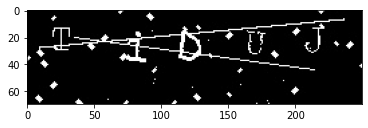

In [ ]:
model = CLSTM()
model.load_state_dict(torch.load('/content/model_CLSTM_bs128_lr0.0001_epoch400'))
drive_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset_processed'
transform = transforms.Compose([transforms.Resize((70,250)),transforms.ToTensor()])
test_data = CAPTCHAImageDataset(drive_path + "/Testing", transform=transform)

# img_path = '/content/gdrive/My Drive/Colab Notebooks/Datasets/project_dataset/Testing/CL97f.jpg'
# img = cv2.imread(img_path)
# print("Original Image")
# cv2_imshow(img)
# print('\n')

# processed_img = remove_noise_and_grayscale(img_path)
# print("Image after pre-processing")
# cv2_imshow(processed_img)
# print('\n')

idx = 560
image = test_data[idx][0]
img_np = image.numpy()
plt.imshow(img_np.transpose(1,2,0)[:,:,0], cmap='gray')
print("Label: {}".format(decode_label(test_data[idx][1])))
pred = model(test_data[idx][0].unsqueeze(0))
print("Model pred: {}".format(decode_pred(pred)))
